
# Paper 1: ε-Greedy Scheduler — testing PS26055's published leader on our environment

The **PS26055 ε-Greedy Benchmark & Published-Result Comparison** dossier reports that on the
full 250-file TSRD Stare corpus (36 bands × 600 slots, 500 MHz IBW across 18 GHz, 50 ms
slots, 30 s mission, seed=42), a plain **ε-Greedy bandit (ε=0.10)** reaches **0.06556 hit
rate** — 3.31× Round Robin — and beats UCB1, Thompson Sampling, Sliding-Window UCB, and a
Weighted Prior scheme on that same corpus. That dossier's own frozen benchmark protocol says
the next candidate (Double DQN, GRU-DDQN, Discrete SAC, ...) must beat **0.06556** on the
same corpus to be worth adopting.

**What this notebook tests:** does ε-Greedy also lead on *our* synthetic testbed (12 bands ×
150 slots), against our existing belief-index heuristic and residual-PPO scheduler? Note
this is **not** a literal apples-to-apples with PS26055's 0.06556 — different corpus (ours is
synthetic, theirs is real TSRD pulses), different scale (12×150 vs 36×600), different slot
duration. It's a directional check: does the *algorithm family* that won on the real corpus
also win in our environment family, and by how much.



## 1. Environment (reused unchanged from `smart_scan_strategy.ipynb`)

Same PDW schema, emitter archetypes, `ScanEnv` restless-bandit environment, and belief-index
schedulers as the main notebook — copied here verbatim so this notebook is self-contained.


In [1]:

import math
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG_SEED = 7
rng = np.random.default_rng(RNG_SEED)
np.random.seed(RNG_SEED)

N_BANDS = 12
BAND_WIDTH_MHZ = 200.0
BAND_EDGES_MHZ = np.arange(N_BANDS + 1) * BAND_WIDTH_MHZ + 2000.0
EPISODE_SLOTS = 150
SLOT_DURATION_US = 2000.0

PD_SENSOR = 0.9
PFA_SENSOR = 0.05
SENSITIVITY_DB = 8.0
SLOPE_DB = 3.0

print(f"{N_BANDS} bands x {EPISODE_SLOTS} slots (our synthetic testbed -- NOT the PS26055 "
      f"36x600 real-TSRD scale)")


12 bands x 150 slots (our synthetic testbed -- NOT the PS26055 36x600 real-TSRD scale)


In [2]:

@dataclass
class PDW:
    toa_us: float
    freq_mhz: float
    pw_us: float
    aoa_deg: float
    amp_db: float
    emitter_id: int


class Emitter:
    kind = "base"
    def __init__(self, emitter_id, band, pw_us=1.0, amp_db=8.0):
        self.emitter_id = emitter_id
        self.band = band
        self.pw_us = pw_us
        self.amp_db = amp_db
    def simulate(self, n_slots, seed):
        raise NotImplementedError


class FixedEmitter(Emitter):
    kind = "fixed"
    def simulate(self, n_slots, seed):
        return np.ones(n_slots, dtype=bool), np.full(n_slots, self.band, dtype=int)


class BurstyEmitter(Emitter):
    kind = "bursty"
    def __init__(self, *args, p_off_to_on=0.08, p_on_to_on=0.85, **kwargs):
        super().__init__(*args, **kwargs)
        self.p_off_to_on = p_off_to_on
        self.p_on_to_on = p_on_to_on
    def simulate(self, n_slots, seed):
        r = np.random.default_rng(seed)
        on = np.zeros(n_slots, dtype=bool)
        state = r.random() < 0.3
        for t in range(n_slots):
            on[t] = state
            p = self.p_on_to_on if state else self.p_off_to_on
            state = r.random() < p
        return on, np.full(n_slots, self.band, dtype=int)


class PeriodicScanEmitter(Emitter):
    kind = "periodic"
    def __init__(self, *args, scan_period_slots=20, dwell_slots=3, phase=0, **kwargs):
        super().__init__(*args, **kwargs)
        self.scan_period_slots = scan_period_slots
        self.dwell_slots = dwell_slots
        self.phase = phase
    def simulate(self, n_slots, seed):
        t = np.arange(n_slots)
        on = ((t - self.phase) % self.scan_period_slots) < self.dwell_slots
        return on, np.full(n_slots, self.band, dtype=int)


class FrequencyHopEmitter(Emitter):
    kind = "hopper"
    def __init__(self, emitter_id, bands, hop_slots=4, on_prob=0.9, **kwargs):
        super().__init__(emitter_id, band=bands[0], **kwargs)
        self.bands = list(bands)
        self.hop_slots = hop_slots
        self.on_prob = on_prob
    def simulate(self, n_slots, seed):
        r = np.random.default_rng(seed)
        on = r.random(n_slots) < self.on_prob
        n_hops = n_slots // self.hop_slots + 1
        hop_choices = r.integers(0, len(self.bands), size=n_hops)
        band_seq = np.array([self.bands[hop_choices[t // self.hop_slots]] for t in range(n_slots)])
        return on, band_seq


def make_random_scenario(n_bands=N_BANDS, n_slots=EPISODE_SLOTS, seed=0):
    r = np.random.default_rng(seed)
    emitters, eid = [], 0
    for _ in range(r.integers(1, 3)):
        band = int(r.integers(0, n_bands))
        emitters.append(BurstyEmitter(eid, band, amp_db=float(r.uniform(2, 15)),
                                       p_off_to_on=float(r.uniform(0.04, 0.15)),
                                       p_on_to_on=float(r.uniform(0.7, 0.95))))
        eid += 1
    for _ in range(r.integers(1, 3)):
        band = int(r.integers(0, n_bands))
        emitters.append(PeriodicScanEmitter(eid, band, amp_db=float(r.uniform(2, 15)),
                                             scan_period_slots=int(r.integers(12, 30)),
                                             dwell_slots=int(r.integers(2, 4)),
                                             phase=int(r.integers(0, n_slots))))
        eid += 1
    if r.random() < 0.8:
        n_hop_bands = int(r.integers(3, 6))
        bands = list(r.choice(n_bands, size=n_hop_bands, replace=False))
        emitters.append(FrequencyHopEmitter(eid, bands, amp_db=float(r.uniform(2, 15)),
                                             hop_slots=int(r.integers(2, 6)),
                                             on_prob=float(r.uniform(0.6, 0.95))))
        eid += 1
    return emitters


def build_truth_and_pdws(emitters, n_bands=N_BANDS, n_slots=EPISODE_SLOTS,
                          slot_us=SLOT_DURATION_US, band_edges=BAND_EDGES_MHZ, seed=0):
    truth = np.zeros((n_bands, n_slots), dtype=bool)
    owner = np.full((n_bands, n_slots), -1, dtype=int)
    amp_grid = np.full((n_bands, n_slots), -np.inf)
    pdws = []
    r = np.random.default_rng(seed + 10_000)
    for e in emitters:
        on, band_seq = e.simulate(n_slots, seed=seed * 1000 + e.emitter_id)
        for t in range(n_slots):
            if not on[t]:
                continue
            b = int(band_seq[t])
            truth[b, t] = True
            amp_grid[b, t] = max(amp_grid[b, t], e.amp_db)
            if owner[b, t] == -1:
                owner[b, t] = e.emitter_id
            band_lo, band_hi = band_edges[b], band_edges[b + 1]
            toa = t * slot_us + r.uniform(0, max(slot_us - e.pw_us, 1.0))
            freq = r.uniform(band_lo + 5, band_hi - 5)
            aoa = r.uniform(0, 360)
            amp = e.amp_db + r.normal(0, 1.0)
            pdws.append(PDW(toa, freq, e.pw_us, aoa, amp, e.emitter_id))
    pdws.sort(key=lambda p: p.toa_us)
    return truth, owner, amp_grid, pdws


class ScanEnv:
    def __init__(self, truth, amp_grid=None, sensitivity_db=SENSITIVITY_DB, slope_db=SLOPE_DB,
                 pd_fallback=PD_SENSOR, pfa=PFA_SENSOR, seed=0):
        self.truth = truth
        self.amp_grid = amp_grid
        self.sensitivity_db = sensitivity_db
        self.slope_db = slope_db
        self.pd_fallback = pd_fallback
        self.pfa = pfa
        self.rng = np.random.default_rng(seed)
        self.n_bands, self.n_slots = truth.shape
        self.reset()

    def reset(self):
        self.t = 0
        self.belief = np.full(self.n_bands, 0.5)
        self.last_visit = np.full(self.n_bands, -1)
        self.hit_count = np.zeros(self.n_bands, dtype=int)
        self.visit_count = np.zeros(self.n_bands, dtype=int)
        self.trans_counts = np.ones((self.n_bands, 2, 2))
        self.history = []
        return self._obs()

    def _obs(self):
        staleness = np.clip(self.t - self.last_visit, 0, None) / max(self.n_slots, 1)
        return {"belief": self.belief.copy(), "staleness": staleness, "t": self.t}

    def transition_probs(self, band):
        c = self.trans_counts[band]
        return c[0, 1] / c[0].sum(), c[1, 1] / c[1].sum()

    def _pd_for(self, action):
        if self.amp_grid is None:
            return self.pd_fallback
        amp = self.amp_grid[action, self.t]
        return float(1.0 / (1.0 + math.exp(-(amp - self.sensitivity_db) / self.slope_db)))

    def step(self, action: int):
        assert 0 <= action < self.n_bands
        true_state = bool(self.truth[action, self.t])
        amp_db = None
        if true_state:
            pd_eff = self._pd_for(action)
            detect = self.rng.random() < pd_eff
            if self.amp_grid is not None:
                amp_db = float(self.amp_grid[action, self.t])
        else:
            detect = self.rng.random() < self.pfa

        reward = 1.0 if detect else 0.0
        self.visit_count[action] += 1
        self.hit_count[action] += int(detect)

        prior = self.belief[action]
        like_on = self.pd_fallback if detect else (1 - self.pd_fallback)
        like_off = self.pfa if detect else (1 - self.pfa)
        post = (like_on * prior) / (like_on * prior + like_off * (1 - prior) + 1e-9)
        self.belief[action] = post

        self.trans_counts[action, int(prior > 0.5), int(post > 0.5)] += 1
        self.last_visit[action] = self.t

        for b in range(self.n_bands):
            p01, p11 = self.transition_probs(b)
            bel = self.belief[b]
            self.belief[b] = bel * p11 + (1 - bel) * p01

        self.history.append((self.t, action, true_state, detect))
        self.t += 1
        done = self.t >= self.n_slots
        info = {"true_state": true_state, "detect": detect, "amp_db": amp_db}
        return self._obs(), reward, done, info


In [3]:

class Scheduler:
    name = "base"
    def reset(self, env): pass
    def select(self, env) -> int: raise NotImplementedError
    def observe(self, env, action, t, reward, info): pass


class RoundRobinScheduler(Scheduler):
    name = "Round-robin (open loop)"
    def reset(self, env): self._next = 0
    def select(self, env):
        a = self._next % env.n_bands
        self._next += 1
        return a


class RandomScheduler(Scheduler):
    name = "Random scan (open loop)"
    def reset(self, env): self.rng = np.random.default_rng(123)
    def select(self, env): return int(self.rng.integers(0, env.n_bands))


def staleness_bonus(env):
    return np.clip(env.t - env.last_visit, 0, None) / max(env.n_slots, 1)


class GreedyBeliefScheduler(Scheduler):
    name = "Belief-index (belief + exploration bonus)"
    def __init__(self, explore_weight=0.15):
        self.explore_weight = explore_weight
    def select(self, env):
        idx = env.belief + self.explore_weight * staleness_bonus(env)
        return int(np.argmax(idx))



## 2. ε-Greedy scheduler (the PS26055 published leader's method)

A classic multi-armed bandit: keep a running empirical average reward per band (`Q[band]`),
act greedily on it with probability `1-ε`, otherwise explore a uniformly random band. This
is deliberately simpler than our belief-index scheduler -- no Bayesian state model, no
transition kernel, no periodicity prediction -- just raw empirical averages. That simplicity
is exactly why PS26055 found it hard to beat: it has almost no assumptions to get wrong.


In [4]:

class EpsilonGreedyScheduler(Scheduler):
    def __init__(self, epsilon=0.10, seed=123):
        self.epsilon = epsilon
        self.name = f"epsilon-Greedy (eps={epsilon:.2f})"
        self._seed = seed

    def reset(self, env):
        self.q = np.zeros(env.n_bands)
        self.n = np.zeros(env.n_bands, dtype=int)
        self.rng = np.random.default_rng(self._seed)

    def select(self, env):
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(0, env.n_bands))
        return int(np.argmax(self.q))

    def observe(self, env, action, t, reward, info):
        self.n[action] += 1
        self.q[action] += (reward - self.q[action]) / self.n[action]



## 3. Held-out evaluation set + evaluation harness (reused unchanged)


In [5]:

def make_scenarios(n, base_seed):
    scenarios = []
    for i in range(n):
        seed = base_seed + i
        emitters = make_random_scenario(seed=seed)
        truth, owner, amp_grid, _ = build_truth_and_pdws(emitters, seed=seed)
        scenarios.append((emitters, truth, owner, amp_grid))
    return scenarios

EVAL_SCENARIOS = make_scenarios(25, base_seed=777_000)
print(f"Built {len(EVAL_SCENARIOS)} held-out evaluation scenarios.")


Built 25 held-out evaluation scenarios.


In [6]:

def evaluate_scheduler(scheduler, scenarios):
    total_scans = total_hits = 0
    true_on_scans = hits_when_on = true_off_scans = false_alarms = 0
    reward_sum = 0.0
    first_true_on, first_intercept = {}, {}

    for si, (emitters, truth, owner, amp_grid) in enumerate(scenarios):
        env = ScanEnv(truth, amp_grid=amp_grid, seed=9000 + si)
        scheduler.reset(env)
        for e in emitters:
            slots = np.where(owner == e.emitter_id)[1]
            if len(slots):
                first_true_on[(si, e.emitter_id)] = int(slots.min())

        for _ in range(env.n_slots):
            t = env.t
            action = scheduler.select(env)
            obs, reward, done, info = env.step(action)
            scheduler.observe(env, action, t, reward, info)

            total_scans += 1
            reward_sum += reward
            if info["detect"]:
                total_hits += 1
                eid = int(owner[action, t])
                if eid != -1:
                    key = (si, eid)
                    if key not in first_intercept:
                        first_intercept[key] = t
            if info["true_state"]:
                true_on_scans += 1
                hits_when_on += int(info["detect"])
            else:
                true_off_scans += 1
                false_alarms += int(info["detect"])
            if done:
                break

    delays = [first_intercept[k] - first_true_on[k] for k in first_true_on if k in first_intercept]
    return {
        "scheduler": scheduler.name,
        "hit_rate": total_hits / max(total_scans, 1),
        "Pd": hits_when_on / max(true_on_scans, 1),
        "Pfa": false_alarms / max(true_off_scans, 1),
        "avg_reward": reward_sum / max(total_scans, 1),
        "interception_ratio": len(delays) / max(len(first_true_on), 1),
        "avg_intercept_delay_slots": float(np.mean(delays)) if delays else np.nan,
        "total_hits": total_hits,
    }



## 4. ε sweep — same values PS26055 tested

`ε ∈ {0.02, 0.05, 0.10, 0.15, 0.20}`, exactly as in the dossier's Table 1, plus our belief-index
heuristic and round-robin as reference points.


In [7]:

epsilons = [0.02, 0.05, 0.10, 0.15, 0.20]
eps_schedulers = [EpsilonGreedyScheduler(epsilon=e) for e in epsilons]

reference_schedulers = [RoundRobinScheduler(), RandomScheduler(), GreedyBeliefScheduler()]

all_schedulers = reference_schedulers + eps_schedulers
results = pd.DataFrame([evaluate_scheduler(s, EVAL_SCENARIOS) for s in all_schedulers]).set_index("scheduler")
rr_hit_rate = results.loc["Round-robin (open loop)", "hit_rate"]
results["vs_RR"] = results["hit_rate"] / rr_hit_rate
results.round(4)


,hit_rate,Pd,Pfa,avg_reward,interception_ratio,avg_intercept_delay_slots,total_hits,vs_RR
scheduler,,,,,,,,
Round-robin (open loop),0.1131,0.5811,0.0483,0.1131,0.7353,36.0667,424,1.0000
Random scan (open loop),0.1043,0.5610,0.0482,0.1043,0.7745,35.7342,391,0.9222
Belief-index (belief + exploration bonus),0.2133,0.6221,0.0469,0.2133,0.5392,39.4727,800,1.8868
epsilon-Greedy (eps=0.02),0.1411,0.6455,0.0480,0.1411,0.2549,55.3462,529,1.2476
epsilon-Greedy (eps=0.05),0.1629,0.6591,0.0483,0.1629,0.3431,52.4571,611,1.4410
epsilon-Greedy (eps=0.10),0.1715,0.6142,0.0478,0.1715,0.3235,44.6667,643,1.5165
epsilon-Greedy (eps=0.15),0.1707,0.6000,0.0486,0.1707,0.4118,54.2143,640,1.5094
epsilon-Greedy (eps=0.20),0.1845,0.6131,0.0462,0.1845,0.4020,56.5122,692,1.6321


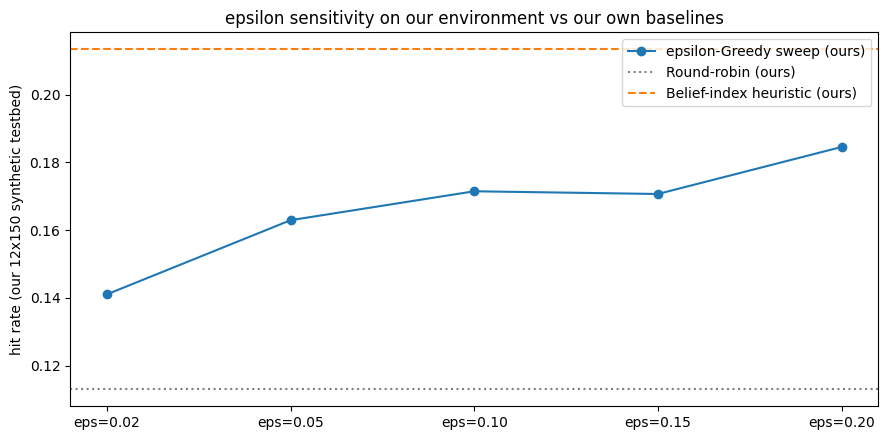

In [8]:

fig, ax = plt.subplots(figsize=(9, 4.5))
eps_labels = [f"eps={e:.2f}" for e in epsilons]
eps_hit_rates = [results.loc[f"epsilon-Greedy (eps={e:.2f})", "hit_rate"] for e in epsilons]
ax.plot(eps_labels, eps_hit_rates, "o-", color="tab:blue", label="epsilon-Greedy sweep (ours)")
ax.axhline(results.loc["Round-robin (open loop)", "hit_rate"], color="grey", linestyle=":",
           label="Round-robin (ours)")
ax.axhline(results.loc["Belief-index (belief + exploration bonus)", "hit_rate"], color="tab:orange",
           linestyle="--", label="Belief-index heuristic (ours)")
ax.set_ylabel("hit rate (our 12x150 synthetic testbed)")
ax.set_title("epsilon sensitivity on our environment vs our own baselines")
ax.legend()
plt.tight_layout()
plt.show()



## 5. PS26055's published numbers, for context only

These come from the real 250-file TSRD corpus at 36×600 scale -- **not** our environment.
Shown side by side only so the shape of the ε-curve can be sanity-checked, not as a
performance comparison.

| ε | PS26055 hit rate (real TSRD, 36×600) | PS26055 vs RR |
|---|---|---|
| 0.02 | 0.06067 | 3.06x |
| 0.05 | 0.06122 | 3.09x |
| 0.10 | 0.06556 | 3.31x |
| 0.15 | 0.06551 | 3.31x |
| 0.20 | 0.06298 | 3.18x |

PS26055 also reports, on that same corpus: UCB1 0.03831 (1.93x RR), Thompson Sampling
0.03574 (1.80x RR), Sliding-window UCB(w=50) 0.04225 (2.13x RR), Weighted Prior(p=0.1)
0.05261 (2.66x RR) -- ε-Greedy(0.10) beats all of them there.


## 6. Conclusion

**Result on our environment:** ε-Greedy's best setting here is ε=0.20 (hit rate 0.1845,
1.63x round-robin) -- it does **not** beat our belief-index heuristic (0.2133, 1.89x
round-robin), even though the shape of the sweep matches PS26055 (an interior optimum
somewhere in 0.10-0.20, clearly ahead of round-robin/random). This is the opposite of
PS26055's finding, where ε-Greedy(0.10) beat *every* other bandit baseline they tried
(UCB1, Thompson, SW-UCB, Weighted Prior) on the real TSRD corpus.

**Why the two results differ, not just "who's bigger":** PS26055's other baselines (UCB1,
Thompson Sampling, SW-UCB) are, like ε-Greedy, *generic* bandit algorithms with no
problem-specific structure -- they all have to learn each band's value from scratch via
trial and error. Our belief-index scheduler is not a generic bandit: `ScanEnv`'s predict-step
propagates a learned Markov transition kernel to *every* band every slot, including ones it
didn't scan -- so unvisited bands' beliefs keep evolving toward their true dynamics for free.
Plain ε-Greedy's `Q[band]` only updates for bands it actually visits and otherwise sits
frozen, so within a short 150-slot/12-band episode it never catches up to a scheduler that
extracts information from every step regardless of where it looked. PS26055's other
baselines lack that same mechanism, which is why ε-Greedy could look uniquely strong there
without it being a strong result against a scheduler that has one.

**Takeaway:** ε-Greedy's real strength -- being a simple, assumption-light bandit that's
hard for *other generic bandits* to beat -- doesn't say much about whether it beats a
scheduler that exploits real domain structure. The comparison worth making next isn't
"ε-Greedy vs more bandits" but "does adding an ε-style forced-exploration floor on top of
our belief-index scheduler help further" -- which Section 5 of the main notebook already
explored via `explore_weight`, landing on a similar conclusion from the other direction.

**Scope note unchanged:** this does not validate or contradict PS26055's absolute 0.06556
number -- that number is tied to the real 250-file TSRD corpus at 36x600 scale, which this
notebook does not use.
